# 🇵🇰 Pakistani Politician Image Classification
### ANN Semester Project — Project 2 (Category B)
**Models:** EfficientNet-B0 & ResNet-50 | **Target:** ≥ 90% Accuracy

## Cell 1 — Install Dependencies

In [3]:
!pip install -q torch torchvision matplotlib seaborn scikit-learn pillow tqdm gradio

## Cell 2 — Mount Google Drive & Set Paths

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ UPDATE THIS to your flat folder of politician images on Drive
RAW_DATA_DIR  = '/content/drive/MyDrive/archive/Dataset'  # <-- CHANGE ME
SPLIT_DATA_DIR = '/content/dataset_split'

print('Drive mounted.')
print('Raw data path:', RAW_DATA_DIR)

Mounted at /content/drive
Drive mounted.
Raw data path: /content/drive/MyDrive/archive/Dataset


In [5]:
# Paste this in a NEW cell and run it
from pathlib import Path

raw = Path(RAW_DATA_DIR)
for d in sorted(raw.iterdir()):
    if d.is_dir():
        all_files = list(d.rglob('*'))  # rglob checks subfolders too
        imgs = [f for f in all_files if f.suffix.lower() in {'.jpg','.jpeg','.png','.webp','.bmp'}]
        print(f'{d.name}: {len(imgs)} images (subfolders: {[x.name for x in d.iterdir() if x.is_dir()]})')

Asad_Umar: 78 images (subfolders: [])
Benazir_Bhutto: 142 images (subfolders: [])
Bilawal Bhutto: 12 images (subfolders: [])
Imran_Khan: 102 images (subfolders: [])
Khawaja_Asif: 94 images (subfolders: [])
Maryam Nawaz: 80 images (subfolders: [])
Mohsin naqvi: 28 images (subfolders: [])
Nawaz_Sharif: 93 images (subfolders: [])
Pervez_Musharraf: 95 images (subfolders: [])
Shah_Mahmood_Qureshi: 144 images (subfolders: [])
Shehbaz_Sharif: 88 images (subfolders: [])
Sheikh Rasheed Ahmed: 80 images (subfolders: [])
Siraj-ul-Haq: 80 images (subfolders: [])
asif_zardari: 84 images (subfolders: [])
pervaiz_elahi: 80 images (subfolders: [])
shireen_mazari: 83 images (subfolders: [])


In [6]:
from pathlib import Path

raw = Path(RAW_DATA_DIR)
problem_classes = ['Bilawal Bhutto', 'Mohsin naqvi', 'Asad_Umar']

for cls in problem_classes:
    cls_path = raw / cls
    print(f'\n=== {cls} ===')
    all_files = list(cls_path.iterdir())
    print(f'Total files: {len(all_files)}')

    # Show all unique extensions found
    extensions = {}
    for f in all_files:
        ext = f.suffix.lower()
        extensions[ext] = extensions.get(ext, 0) + 1
    print(f'Extensions found: {extensions}')

    # Show first 5 filenames
    print('Sample filenames:')
    for f in list(all_files)[:5]:
        print(f'  {f.name}')



=== Bilawal Bhutto ===
Total files: 80
Extensions found: {'.jfif': 68, '.webp': 5, '.jpg': 7}
Sample filenames:
  3.jfif
  25.jfif
  28.jfif
  26.jfif
  14.webp

=== Mohsin naqvi ===
Total files: 80
Extensions found: {'.jfif': 52, '.jpg': 7, '.jpeg': 21}
Sample filenames:
  11.jfif
  16.jfif
  12.jfif
  13.jfif
  14.jfif

=== Asad_Umar ===
Total files: 81
Extensions found: {'.jpg': 78, '.jfif': 3}
Sample filenames:
  35.jpg
  20.jpg
  19.jpg
  13.jpg
  33.jpg


## Cell 3 — Split Dataset (75% Train / 15% Val / 10% Test)

In [7]:
# Fix: Add .jfif to allowed extensions then rerun split
import os, shutil, random
from pathlib import Path

random.seed(42)
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.75, 0.15, 0.10

# ✅ Added .jfif here
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.jfif'}

raw   = Path(RAW_DATA_DIR)
split = Path(SPLIT_DATA_DIR)

# Clear old split first
if split.exists():
    shutil.rmtree(split)
    print('Cleared old split')

subdirs = [d for d in raw.iterdir() if d.is_dir()]
class_to_files = {}
for d in subdirs:
    imgs = [f for f in d.iterdir() if f.suffix.lower() in IMG_EXTS]
    if imgs:
        class_to_files[d.name] = imgs

print(f'\nFound {len(class_to_files)} classes:')
for cls, imgs in sorted(class_to_files.items()):
    print(f'  {cls}: {len(imgs)} images')

for split_name in ['train', 'val', 'test']:
    (split / split_name).mkdir(parents=True, exist_ok=True)

for cls, imgs in class_to_files.items():
    random.shuffle(imgs)
    n = len(imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    splits_map = {
        'train': imgs[:n_train],
        'val'  : imgs[n_train:n_train + n_val],
        'test' : imgs[n_train + n_val:]
    }
    for split_name, file_list in splits_map.items():
        dest = split / split_name / cls
        dest.mkdir(parents=True, exist_ok=True)
        for f in file_list:
            shutil.copy2(f, dest / f.name)

print('\n✅ Split complete!')
for cls, imgs in sorted(class_to_files.items()):
    print(f'  {cls}: {len(imgs)} total images')


Found 16 classes:
  Asad_Umar: 81 images
  Benazir_Bhutto: 142 images
  Bilawal Bhutto: 80 images
  Imran_Khan: 102 images
  Khawaja_Asif: 94 images
  Maryam Nawaz: 80 images
  Mohsin naqvi: 80 images
  Nawaz_Sharif: 93 images
  Pervez_Musharraf: 95 images
  Shah_Mahmood_Qureshi: 144 images
  Shehbaz_Sharif: 88 images
  Sheikh Rasheed Ahmed: 80 images
  Siraj-ul-Haq: 80 images
  asif_zardari: 96 images
  pervaiz_elahi: 80 images
  shireen_mazari: 83 images

✅ Split complete!
  Asad_Umar: 81 total images
  Benazir_Bhutto: 142 total images
  Bilawal Bhutto: 80 total images
  Imran_Khan: 102 total images
  Khawaja_Asif: 94 total images
  Maryam Nawaz: 80 total images
  Mohsin naqvi: 80 total images
  Nawaz_Sharif: 93 total images
  Pervez_Musharraf: 95 total images
  Shah_Mahmood_Qureshi: 144 total images
  Shehbaz_Sharif: 88 total images
  Sheikh Rasheed Ahmed: 80 total images
  Siraj-ul-Haq: 80 total images
  asif_zardari: 96 total images
  pervaiz_elahi: 80 total images
  shireen_maza

## Cell 4 — Augmentation & DataLoaders

In [8]:
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

BATCH_SIZE  = 32
IMG_SIZE    = 224
NUM_WORKERS = 2

train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.3, contrast=0.2),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(SPLIT_DATA_DIR + '/train', transform=train_transforms)
val_ds   = ImageFolder(SPLIT_DATA_DIR + '/val',   transform=val_test_transforms)
test_ds  = ImageFolder(SPLIT_DATA_DIR + '/test',  transform=val_test_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Device: {DEVICE}')

Classes (16): ['Asad_Umar', 'Benazir_Bhutto', 'Bilawal Bhutto', 'Imran_Khan', 'Khawaja_Asif', 'Maryam Nawaz', 'Mohsin naqvi', 'Nawaz_Sharif', 'Pervez_Musharraf', 'Shah_Mahmood_Qureshi', 'Shehbaz_Sharif', 'Sheikh Rasheed Ahmed', 'Siraj-ul-Haq', 'asif_zardari', 'pervaiz_elahi', 'shireen_mazari']
Train: 1020 | Val: 203 | Test: 140
Device: cuda


## Cell 5 — Class Distribution Chart

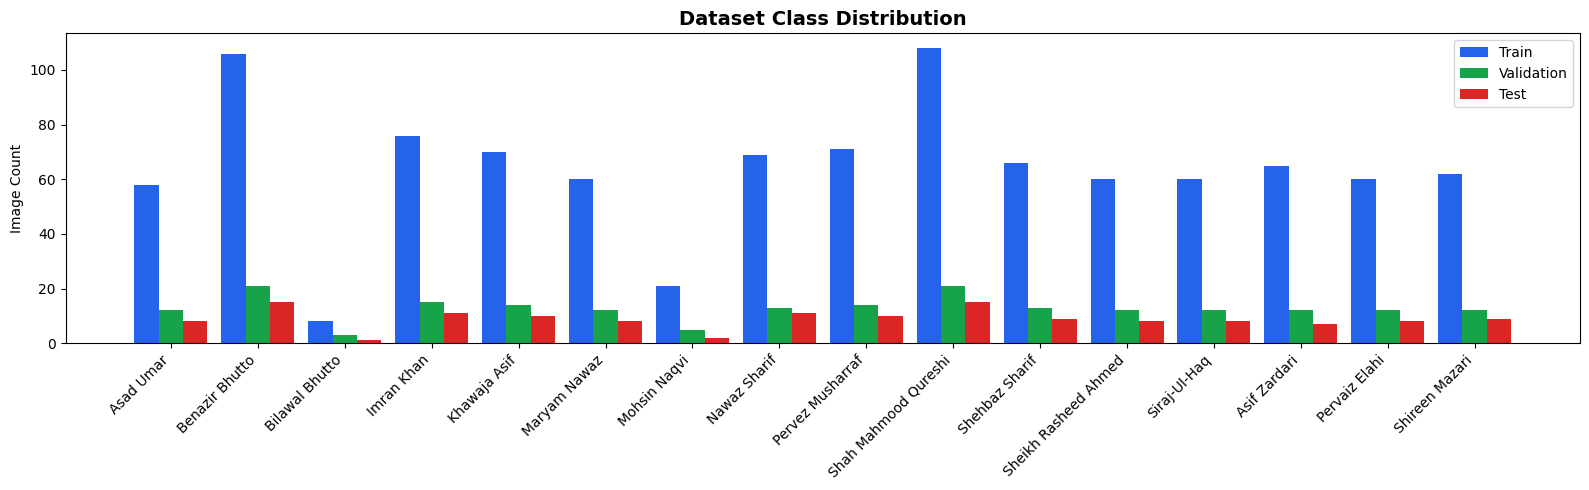

Saved: class_distribution.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

train_counts = Counter(train_ds.targets)
val_counts   = Counter(val_ds.targets)
test_counts  = Counter(test_ds.targets)

x = np.arange(NUM_CLASSES)
w = 0.28
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w, [train_counts[i] for i in x], w, label='Train',      color='#2563EB')
ax.bar(x,     [val_counts[i]   for i in x], w, label='Validation', color='#16A34A')
ax.bar(x + w, [test_counts[i]  for i in x], w, label='Test',       color='#DC2626')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_',' ').title() for c in CLASS_NAMES], rotation=45, ha='right')
ax.set_title('Dataset Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Image Count')
ax.legend()
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('Saved: class_distribution.png')

## Cell 6 — Build Models (EfficientNet-B0 & ResNet-50)

In [10]:
import torch.nn as nn
from torchvision import models

def build_efficientnet_b0(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for name, param in model.named_parameters():
        if 'features.7' in name or 'features.8' in name or 'classifier' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model

def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for name, param in model.named_parameters():
        if 'layer4' in name or 'fc' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(512, num_classes)
    )
    return model

effnet = build_efficientnet_b0(NUM_CLASSES)
resnet = build_resnet50(NUM_CLASSES)

for name, mdl in [('EfficientNet-B0', effnet), ('ResNet-50', resnet)]:
    total     = sum(p.numel() for p in mdl.parameters())
    trainable = sum(p.numel() for p in mdl.parameters() if p.requires_grad)
    print(f'{name}: {total:,} total | {trainable:,} trainable params')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 82.4MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


EfficientNet-B0: 4,671,628 total | 1,793,472 trainable params
ResNet-50: 24,565,328 total | 16,022,032 trainable params


## Cell 7 — Training Loop

In [22]:
import time
from tqdm import tqdm

def train_model(model, model_name, num_epochs=10, lr=1e-3):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_weights = 0.0, None

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for imgs, labels in tqdm(train_loader, desc=f'[{model_name}] Epoch {epoch}/{num_epochs}', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * imgs.size(0)
            t_correct += (out.argmax(1) == labels).sum().item()
            t_total   += imgs.size(0)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)

        scheduler.step()
        tl = t_loss/t_total; vl = v_loss/v_total
        ta = t_correct/t_total*100; va = v_correct/v_total*100
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        if va > best_val_acc:
            best_val_acc = va
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'[{model_name}] Ep {epoch:02d} | Train Loss:{tl:.4f} Acc:{ta:.2f}% | Val Loss:{vl:.4f} Acc:{va:.2f}% | {time.time()-t0:.1f}s')

    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), f'{model_name.lower().replace("-","_")}_best.pth')
    print(f'Best Val Acc for {model_name}: {best_val_acc:.2f}%')
    return model, history

print('Train function ready. Run Cell 8 and Cell 9 to train.')

Train function ready. Run Cell 8 and Cell 9 to train.


## Cell 8 — Train EfficientNet-B0

In [23]:
effnet_model, effnet_history = train_model(effnet, 'EfficientNet-B0')

[EfficientNet-B0] Ep 01 | Train Loss:0.8211 Acc:93.63% | Val Loss:1.0575 Acc:82.27% | 13.4s


[EfficientNet-B0] Ep 02 | Train Loss:0.8012 Acc:94.12% | Val Loss:0.9358 Acc:88.18% | 15.5s


[EfficientNet-B0] Ep 03 | Train Loss:0.7231 Acc:97.35% | Val Loss:0.8839 Acc:89.16% | 13.0s


[EfficientNet-B0] Ep 04 | Train Loss:0.6888 Acc:98.82% | Val Loss:0.7979 Acc:92.61% | 12.8s


[EfficientNet-B0] Ep 05 | Train Loss:0.6555 Acc:99.31% | Val Loss:0.7796 Acc:93.60% | 12.6s


[EfficientNet-B0] Ep 06 | Train Loss:0.6392 Acc:99.80% | Val Loss:0.7730 Acc:93.60% | 11.8s


[EfficientNet-B0] Ep 07 | Train Loss:0.6262 Acc:99.61% | Val Loss:0.7734 Acc:93.60% | 11.4s


[EfficientNet-B0] Ep 08 | Train Loss:0.6135 Acc:100.00% | Val Loss:0.7557 Acc:95.57% | 13.1s


[EfficientNet-B0] Ep 09 | Train Loss:0.6134 Acc:99.90% | Val Loss:0.7501 Acc:94.09% | 13.1s


[EfficientNet-B0] Ep 10 | Train Loss:0.6109 Acc:100.00% | Val Loss:0.7507 Acc:93.60% | 13.1s
Best Val Acc for EfficientNet-B0: 95.57%


## Cell 9 — Train ResNet-50

In [24]:
resnet_model, resnet_history = train_model(resnet, 'ResNet-50')

[ResNet-50] Ep 01 | Train Loss:0.7918 Acc:94.02% | Val Loss:0.9627 Acc:86.70% | 12.9s


[ResNet-50] Ep 02 | Train Loss:0.7851 Acc:93.73% | Val Loss:0.9452 Acc:86.21% | 11.5s


[ResNet-50] Ep 03 | Train Loss:0.7449 Acc:96.47% | Val Loss:0.9143 Acc:89.66% | 12.1s


[ResNet-50] Ep 04 | Train Loss:0.7095 Acc:97.06% | Val Loss:0.8434 Acc:89.16% | 12.7s


[ResNet-50] Ep 05 | Train Loss:0.6989 Acc:97.45% | Val Loss:0.9188 Acc:89.66% | 12.9s


[ResNet-50] Ep 06 | Train Loss:0.6507 Acc:99.12% | Val Loss:0.7975 Acc:91.63% | 12.6s


[ResNet-50] Ep 07 | Train Loss:0.6353 Acc:99.22% | Val Loss:0.7998 Acc:91.63% | 11.9s


[ResNet-50] Ep 08 | Train Loss:0.6286 Acc:99.51% | Val Loss:0.7606 Acc:92.12% | 11.3s


[ResNet-50] Ep 09 | Train Loss:0.6198 Acc:99.51% | Val Loss:0.7578 Acc:93.10% | 13.1s


[ResNet-50] Ep 10 | Train Loss:0.6182 Acc:99.61% | Val Loss:0.7550 Acc:93.10% | 13.1s
Best Val Acc for ResNet-50: 93.10%


## Cell 10 — Training vs Validation Curves

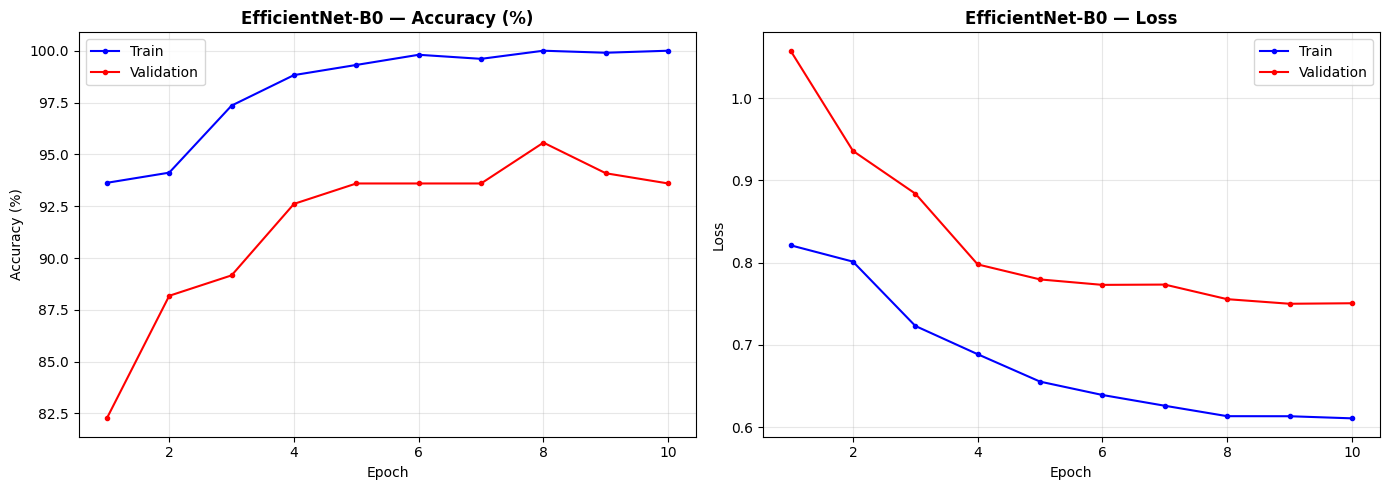

Saved: efficientnet_b0_curves.png


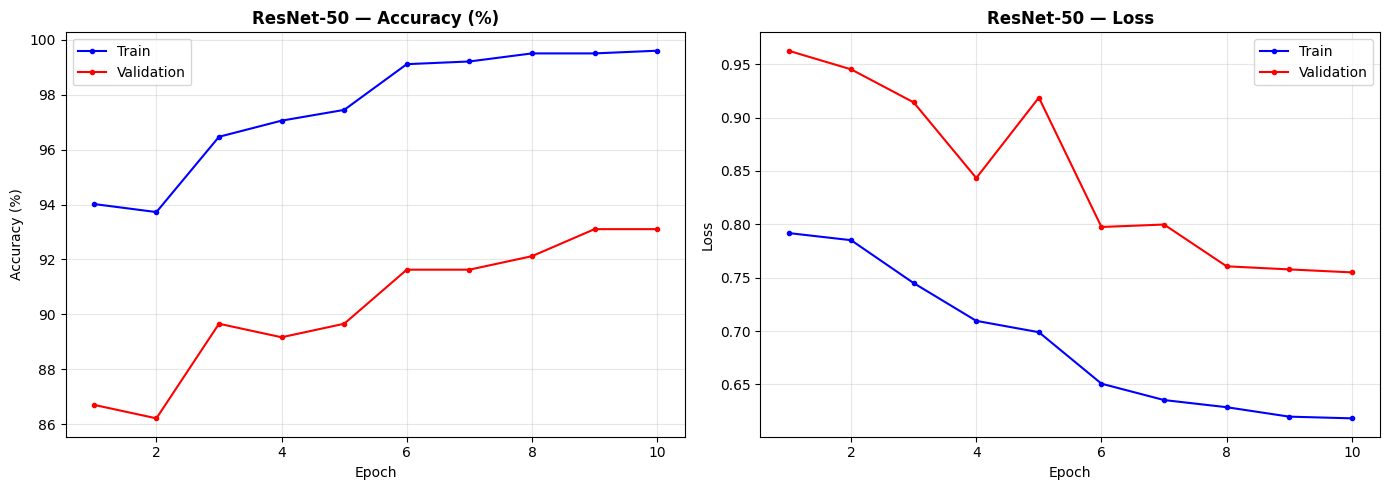

Saved: resnet_50_curves.png


In [25]:
def plot_curves(history, model_name):
    epochs = range(1, len(history['train_acc']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, title in zip(axes, ['acc','loss'], ['Accuracy (%)','Loss']):
        ax.plot(epochs, history[f'train_{metric}'], 'b-o', ms=3, label='Train')
        ax.plot(epochs, history[f'val_{metric}'],   'r-o', ms=3, label='Validation')
        ax.set_title(f'{model_name} — {title}', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(title)
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = f'{model_name.lower().replace("-","_")}_curves.png'
    plt.savefig(fname, dpi=150); plt.show()
    print(f'Saved: {fname}')

plot_curves(effnet_history, 'EfficientNet-B0')
plot_curves(resnet_history, 'ResNet-50')

## Cell 11 — Test Set Evaluation (Accuracy, Precision, Recall, F1)

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_on_test(model, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            out = model(imgs.to(DEVICE))
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds) * 100
    print(f'\n{model_name} — Test Accuracy: {acc:.2f}%')
    print(classification_report(
        all_labels, all_preds,
        target_names=[c.replace('_',' ').title() for c in CLASS_NAMES],
        digits=4
    ))
    return all_labels, all_preds, acc

effnet_labels, effnet_preds, effnet_acc = evaluate_on_test(effnet_model, 'EfficientNet-B0')
resnet_labels, resnet_preds, resnet_acc = evaluate_on_test(resnet_model, 'ResNet-50')


EfficientNet-B0 — Test Accuracy: 93.57%
                      precision    recall  f1-score   support

           Asad Umar     1.0000    0.8750    0.9333         8
      Benazir Bhutto     0.8333    1.0000    0.9091        15
      Bilawal Bhutto     1.0000    1.0000    1.0000         1
          Imran Khan     0.8333    0.9091    0.8696        11
        Khawaja Asif     1.0000    1.0000    1.0000        10
        Maryam Nawaz     1.0000    1.0000    1.0000         8
        Mohsin Naqvi     1.0000    1.0000    1.0000         2
        Nawaz Sharif     1.0000    1.0000    1.0000        11
    Pervez Musharraf     0.8889    0.8000    0.8421        10
Shah Mahmood Qureshi     0.9375    1.0000    0.9677        15
      Shehbaz Sharif     0.8182    1.0000    0.9000         9
Sheikh Rasheed Ahmed     1.0000    1.0000    1.0000         8
        Siraj-Ul-Haq     1.0000    1.0000    1.0000         8
        Asif Zardari     1.0000    0.7143    0.8333         7
       Pervaiz Elahi     1.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Cell 12 — Confusion Matrix Heatmaps

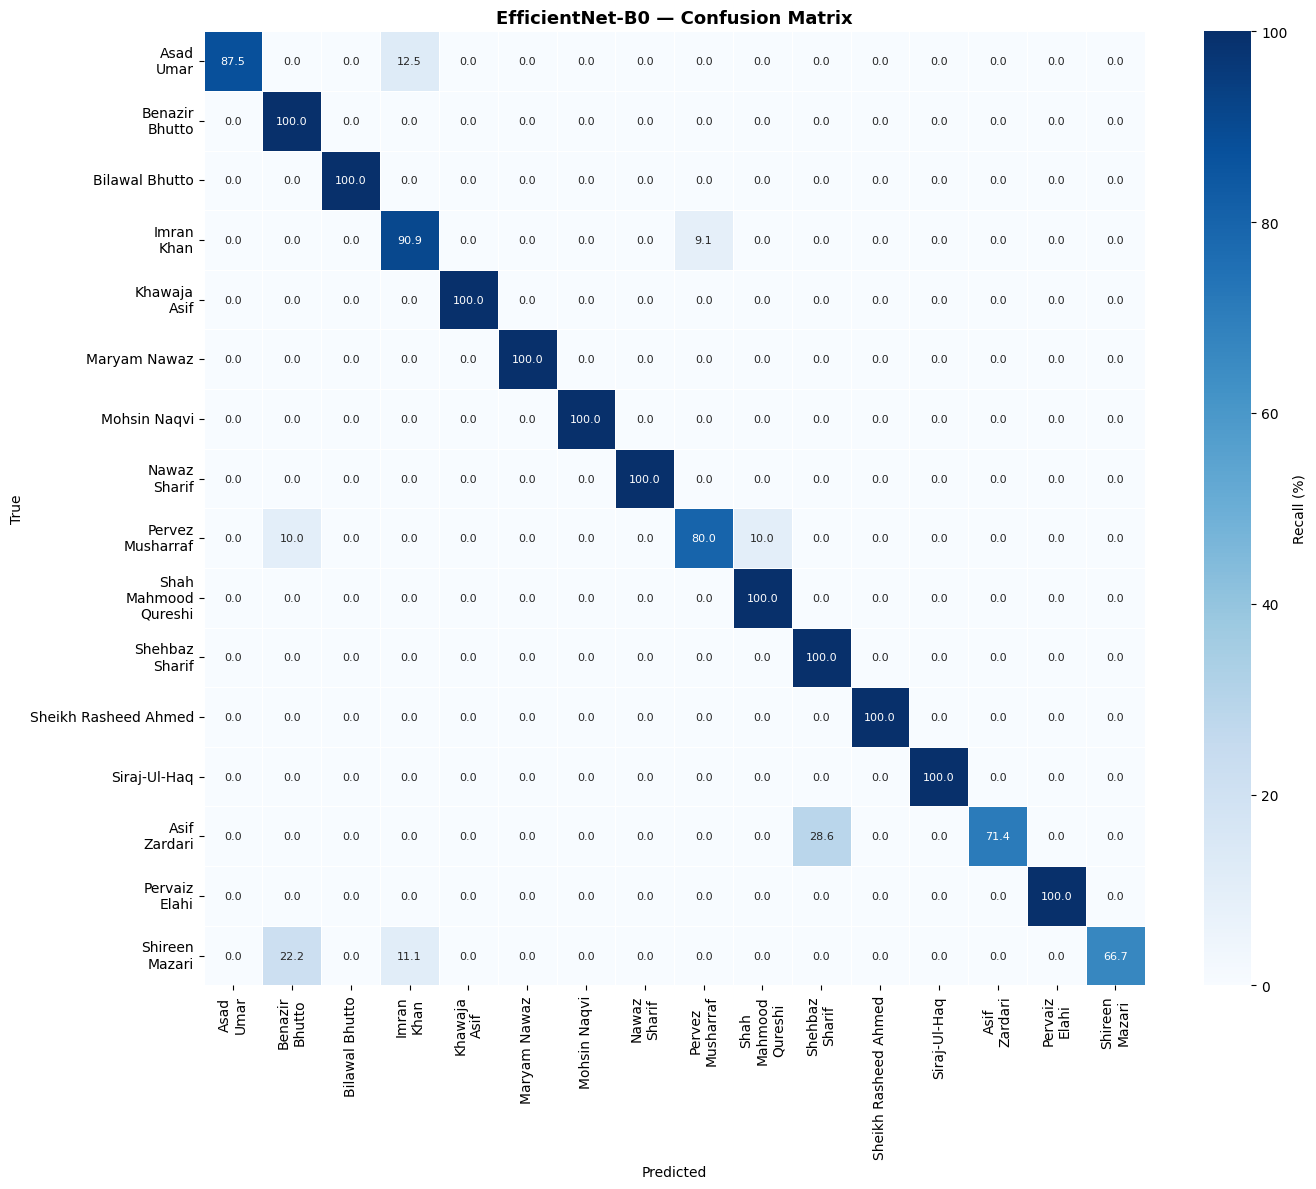

Saved: efficientnet_b0_confusion_matrix.png


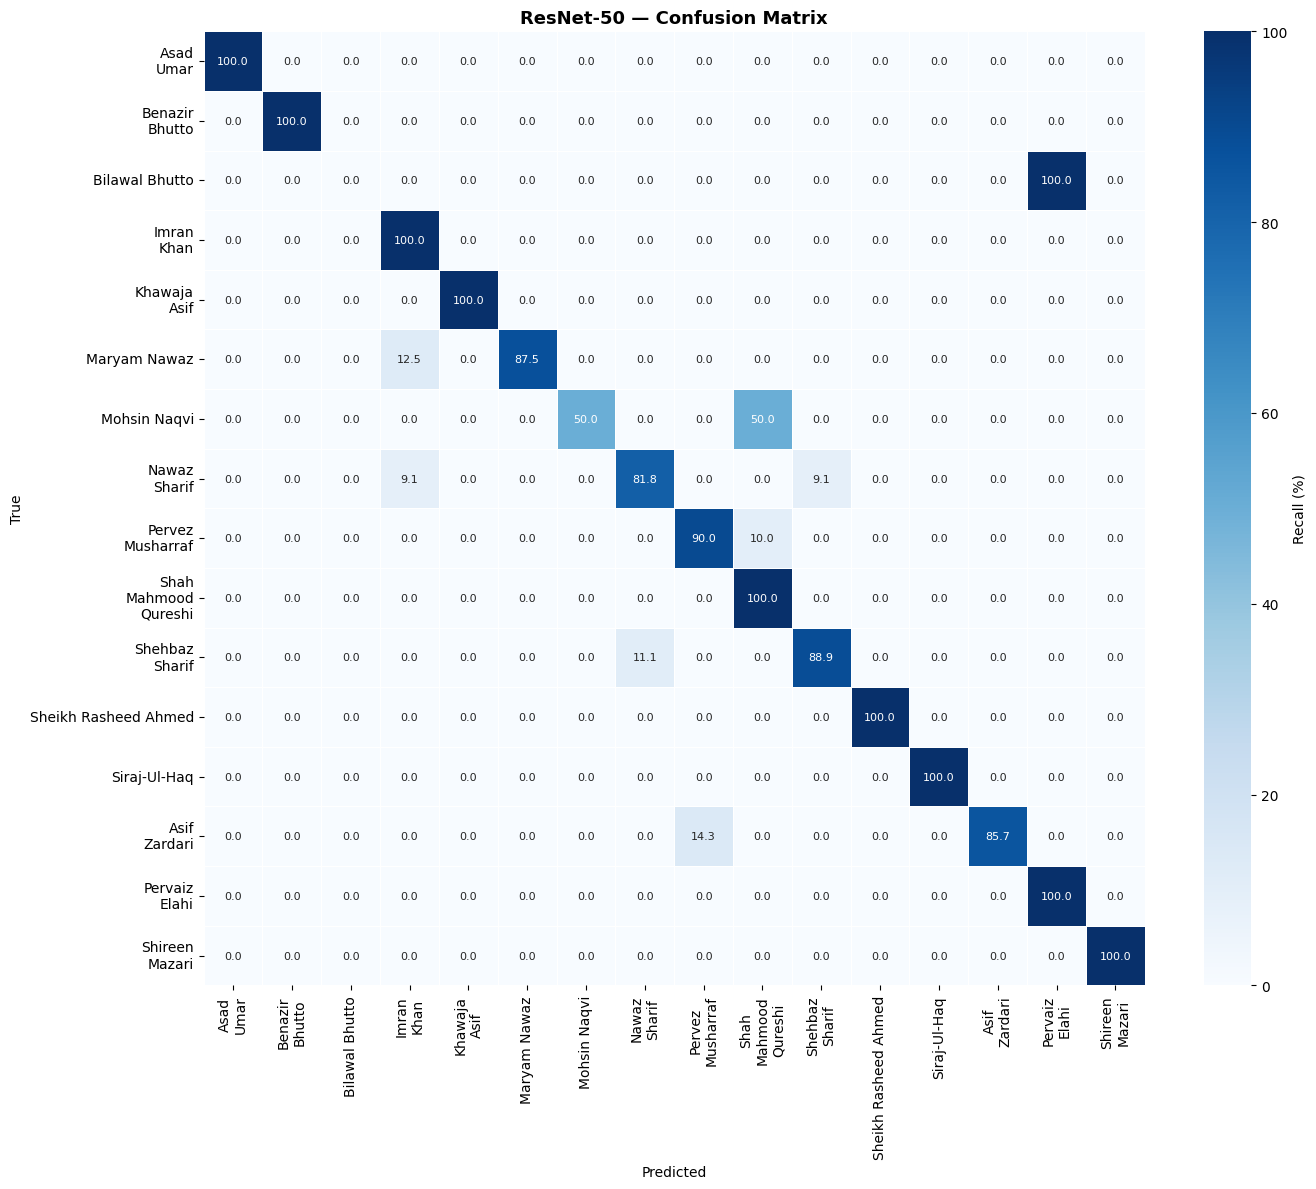

Saved: resnet_50_confusion_matrix.png


In [27]:
import seaborn as sns

def plot_confusion_matrix(labels, preds, model_name):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    tick_labels = [c.replace('_','\n').title() for c in CLASS_NAMES]
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=tick_labels, yticklabels=tick_labels,
                linewidths=0.5, ax=ax, annot_kws={'size': 8},
                cbar_kws={'label': 'Recall (%)'})
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'{model_name.lower().replace("-","_")}_confusion_matrix.png'
    plt.savefig(fname, dpi=150); plt.show()
    print(f'Saved: {fname}')

plot_confusion_matrix(effnet_labels, effnet_preds, 'EfficientNet-B0')
plot_confusion_matrix(resnet_labels, resnet_preds, 'ResNet-50')

## Cell 13 — Top 5 Misclassified Samples

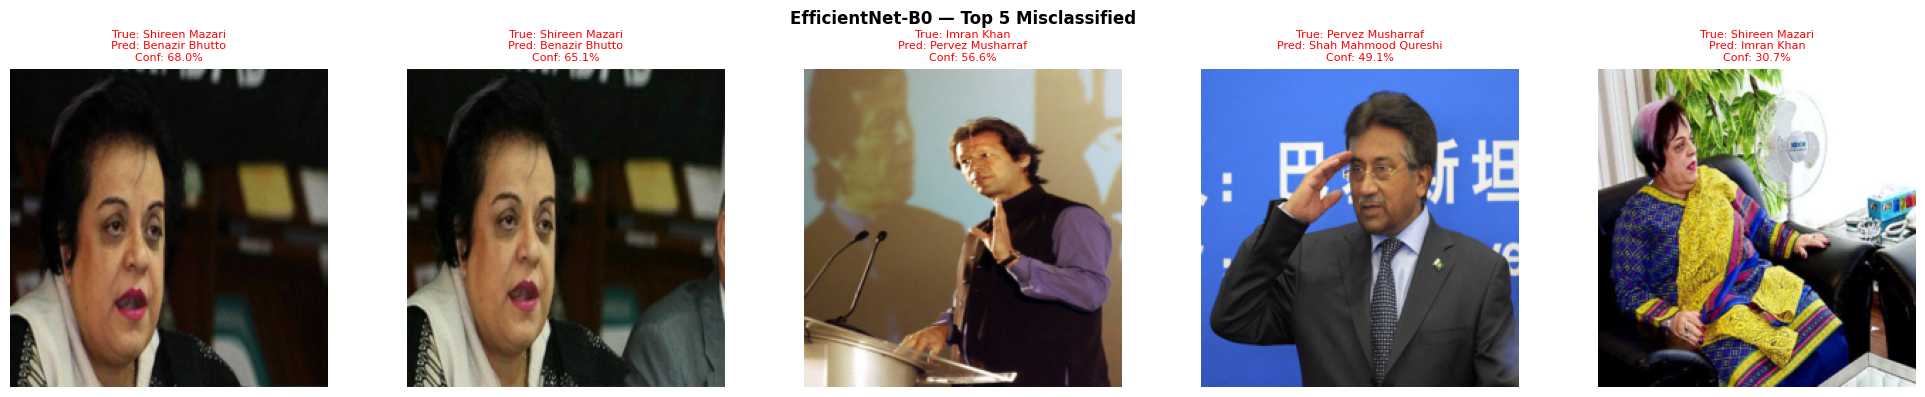

Saved: efficientnet_b0_misclassified.png


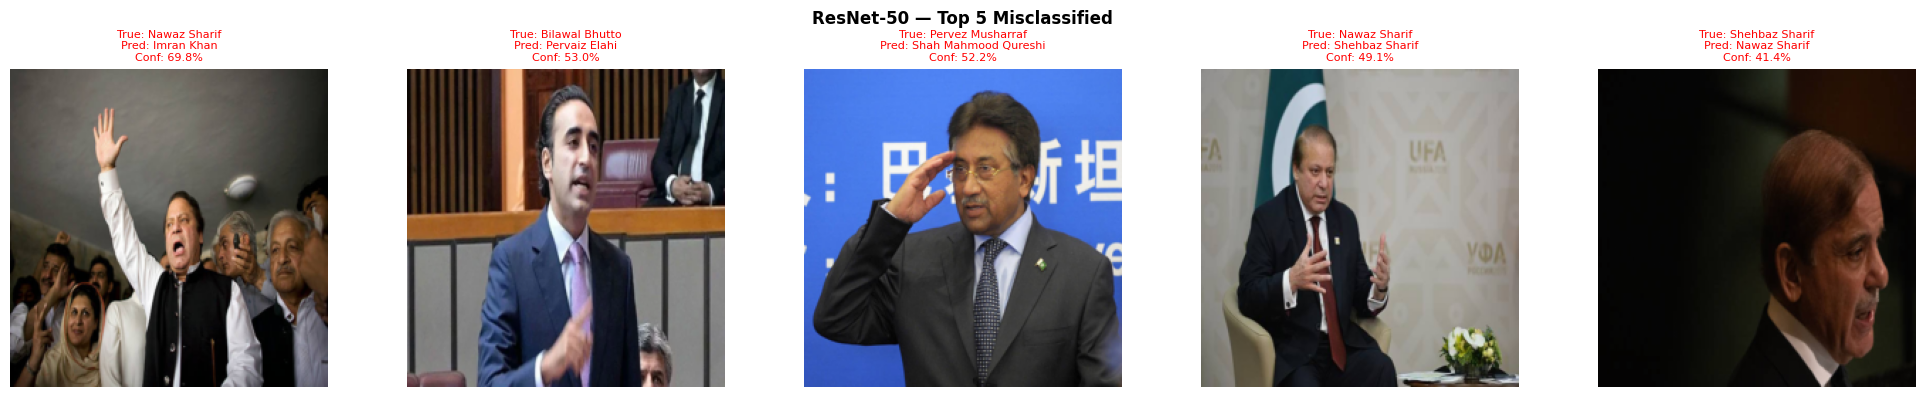

Saved: resnet_50_misclassified.png


In [28]:
def show_misclassified(model, model_name, top_n=5):
    model.eval()
    misclassified = []
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    with torch.no_grad():
        for imgs, labels in test_loader:
            out   = model(imgs.to(DEVICE))
            probs = torch.softmax(out, dim=1).cpu()
            confs, preds = probs.max(dim=1)
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append((imgs[i], labels[i].item(), preds[i].item(), confs[i].item()))
    misclassified.sort(key=lambda x: x[3], reverse=True)
    misclassified = misclassified[:top_n]
    fig, axes = plt.subplots(1, top_n, figsize=(4*top_n, 4))
    fig.suptitle(f'{model_name} — Top {top_n} Misclassified', fontsize=12, fontweight='bold')
    for ax, (img_t, true, pred, conf) in zip(axes, misclassified):
        img = (img_t * std + mean).clamp(0,1).permute(1,2,0).numpy()
        ax.imshow(img)
        ax.set_title(f'True: {CLASS_NAMES[true].replace("_"," ").title()}\nPred: {CLASS_NAMES[pred].replace("_"," ").title()}\nConf: {conf*100:.1f}%', fontsize=8, color='red')
        ax.axis('off')
    plt.tight_layout()
    fname = f'{model_name.lower().replace("-","_")}_misclassified.png'
    plt.savefig(fname, dpi=150); plt.show()
    print(f'Saved: {fname}')

show_misclassified(effnet_model, 'EfficientNet-B0')
show_misclassified(resnet_model, 'ResNet-50')

## Cell 14 — Model Comparison Table & Chart

                 Accuracy (%)  Macro Precision  Macro Recall  Macro F1
EfficientNet-B0         93.57           0.9570        0.9353    0.9409
ResNet-50               94.29           0.8941        0.8650    0.8728


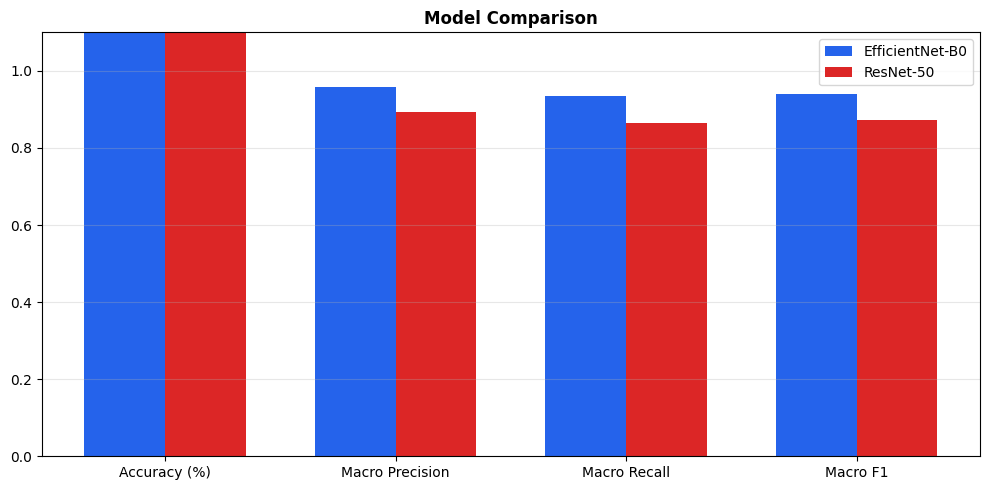

Saved: model_comparison_chart.png  |  model_comparison.csv


In [29]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def summary(labels, preds):
    return {
        'Accuracy (%)' : round(accuracy_score(labels, preds)*100, 2),
        'Macro Precision': round(precision_score(labels, preds, average='macro', zero_division=0), 4),
        'Macro Recall'   : round(recall_score(labels,   preds, average='macro', zero_division=0), 4),
        'Macro F1'       : round(f1_score(labels,       preds, average='macro', zero_division=0), 4),
    }

results = {
    'EfficientNet-B0': summary(effnet_labels, effnet_preds),
    'ResNet-50'      : summary(resnet_labels, resnet_preds),
}
df = pd.DataFrame(results).T
print(df.to_string())
df.to_csv('model_comparison.csv')

metrics = list(list(results.values())[0].keys())
x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w/2, [results['EfficientNet-B0'][m] for m in metrics], w, label='EfficientNet-B0', color='#2563EB')
ax.bar(x+w/2, [results['ResNet-50'][m]       for m in metrics], w, label='ResNet-50',       color='#DC2626')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_title('Model Comparison', fontweight='bold')
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150); plt.show()
print('Saved: model_comparison_chart.png  |  model_comparison.csv')

## Cell 15 — Save All Outputs to Google Drive

In [30]:
import shutil

OUTPUT_DRIVE = '/content/drive/MyDrive/politician_classification_outputs'
os.makedirs(OUTPUT_DRIVE, exist_ok=True)

files_to_save = [
    'efficientnet_b0_best.pth', 'resnet_50_best.pth',
    'class_distribution.png',
    'efficientnet_b0_curves.png', 'resnet_50_curves.png',
    'efficientnet_b0_confusion_matrix.png', 'resnet_50_confusion_matrix.png',
    'efficientnet_b0_misclassified.png', 'resnet_50_misclassified.png',
    'model_comparison.csv', 'model_comparison_chart.png',
]

for fname in files_to_save:
    src = Path(fname)
    if src.exists():
        shutil.copy2(src, OUTPUT_DRIVE)
        print(f'Copied: {fname}')
    else:
        print(f'Not found (run earlier cells first): {fname}')

print(f'Done! Outputs at: {OUTPUT_DRIVE}')

Copied: efficientnet_b0_best.pth
Copied: resnet_50_best.pth
Copied: class_distribution.png
Copied: efficientnet_b0_curves.png
Copied: resnet_50_curves.png
Copied: efficientnet_b0_confusion_matrix.png
Copied: resnet_50_confusion_matrix.png
Copied: efficientnet_b0_misclassified.png
Copied: resnet_50_misclassified.png
Copied: model_comparison.csv
Copied: model_comparison_chart.png
Done! Outputs at: /content/drive/MyDrive/politician_classification_outputs


## Cell 16 — Gradio Frontend for Testing

In [31]:
import gradio as gr
from PIL import Image

BEST_MODEL = effnet_model if effnet_acc >= resnet_acc else resnet_model
BEST_NAME  = 'EfficientNet-B0' if effnet_acc >= resnet_acc else 'ResNet-50'
BEST_MODEL.eval()

infer_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict(image: Image.Image):
    tensor = infer_tf(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(BEST_MODEL(tensor), dim=1)[0].cpu().numpy()
    top5  = probs.argsort()[::-1][:5]
    return {CLASS_NAMES[i].replace('_',' ').title(): float(probs[i]) for i in top5}

gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil', label='Upload Politician Image'),
    outputs=gr.Label(num_top_classes=5, label='Top-5 Predictions'),
    title='Pakistani Politician Classifier',
    description=f'Model: {BEST_NAME} | Accuracy: {max(effnet_acc, resnet_acc):.2f}%',
    theme=gr.themes.Soft()
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8dc7c45e193c08318.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
